In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import pickle
import warnings
import os
warnings.filterwarnings('ignore')

# 1. Load Data
books = pd.read_csv('data/Books.csv', low_memory=False)
users = pd.read_csv('data/Users.csv')
ratings = pd.read_csv('data/Ratings.csv')

In [90]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [91]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [92]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [93]:
print(books.shape)

(271360, 8)


In [94]:
print(users.shape)

(278858, 3)


In [95]:
print(ratings.shape)

(1149780, 3)


In [96]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [97]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [98]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [99]:
books.duplicated().sum()

np.int64(0)

In [100]:
users.duplicated().sum()

np.int64(0)

In [101]:
ratings.duplicated().sum()

np.int64(0)

In [102]:
# Set visualization style
sns.set_theme(style="darkgrid")

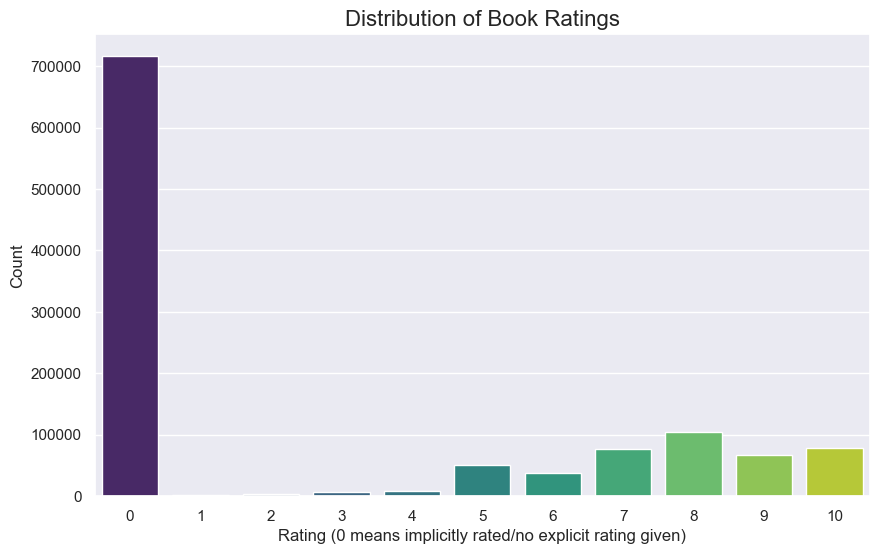

In [103]:
# EDA 1: Distribution of Book Ratings
# We want to see how users generally rate books. Are they generous or critical?
plt.figure(figsize=(10, 6))
sns.countplot(x='Book-Rating', data=ratings, palette='viridis')
plt.title('Distribution of Book Ratings', fontsize=16)
plt.xlabel('Rating (0 means implicitly rated/no explicit rating given)')
plt.ylabel('Count')
plt.show()

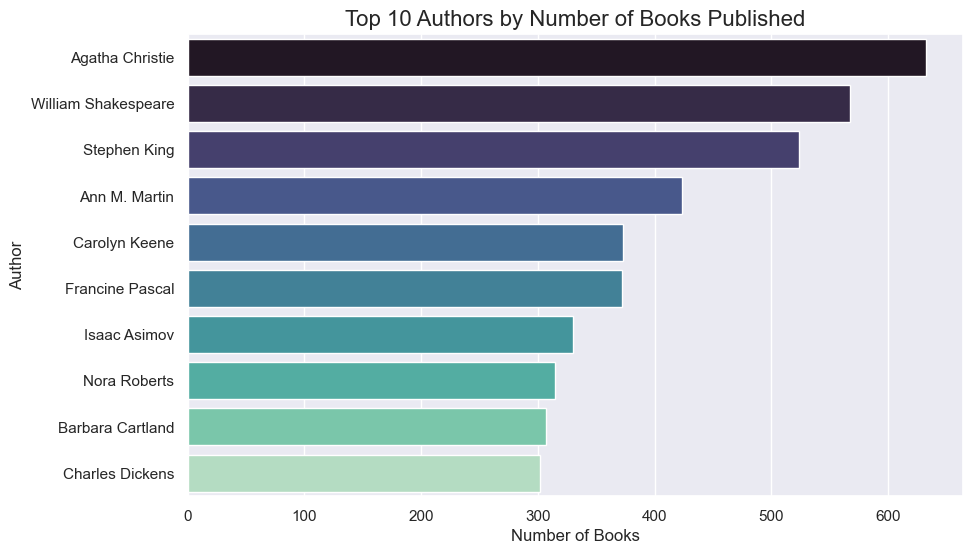

In [104]:
# EDA 2: Top 10 Authors with the Most Books
plt.figure(figsize=(10, 6))
top_authors = books['Book-Author'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, palette='mako')
plt.title('Top 10 Authors by Number of Books Published', fontsize=16)
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.show()

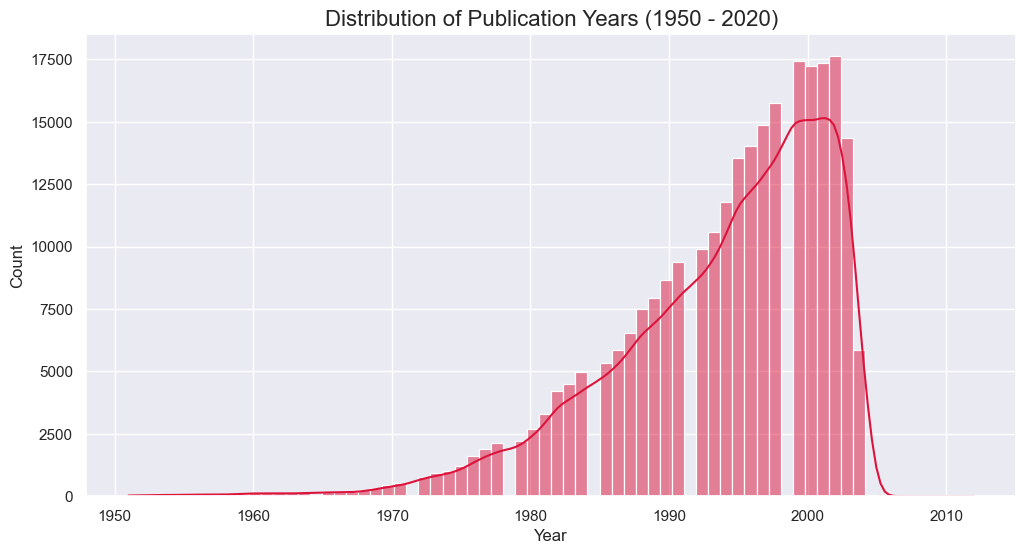

In [105]:
# EDA 3: Year of Publication Distribution (Zoomed in on 1950-2020)
# We convert to numeric, coercing errors to NaN, then drop them for the plot
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
plt.figure(figsize=(12, 6))
sns.histplot(books[(books['Year-Of-Publication'] > 1950) & (books['Year-Of-Publication'] < 2020)]['Year-Of-Publication'], bins=70, kde=True, color='crimson')
plt.title('Distribution of Publication Years (1950 - 2020)', fontsize=16)
plt.xlabel('Year')
plt.show()

In [106]:
# Keep only necessary columns in Books
books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-L']]

# Rename columns for easier coding
books.rename(columns={'Book-Title': 'title', 'Book-Author': 'author', 'Year-Of-Publication': 'year', 'Publisher': 'publisher', 'Image-URL-L': 'image_url'}, inplace=True)
ratings.rename(columns={'User-ID': 'user_id', 'Book-Rating': 'rating'}, inplace=True)

# Merge Ratings with Books so we have titles alongside the ratings
ratings_with_name = ratings.merge(books, on='ISBN')

# Checking the merged data
print("Merged Data Shape:", ratings_with_name.shape)

Merged Data Shape: (1031136, 8)


In [107]:
# 1. Filtering for Prolific Users (Users who have rated > 200 books)
x = ratings_with_name.groupby('user_id').count()['rating'] > 200
prolific_users = x[x].index
filtered_rating = ratings_with_name[ratings_with_name['user_id'].isin(prolific_users)]

# 2. Filtering for Famous Books (Books that have received >= 50 ratings from our prolific users)
y = filtered_rating.groupby('title').count()['rating'] >= 50
famous_books = y[y].index
final_ratings = filtered_rating[filtered_rating['title'].isin(famous_books)]

# 3. Creating the Pivot Table
# Rows = Book Titles, Columns = User IDs, Values = Ratings
pt = final_ratings.pivot_table(index='title', columns='user_id', values='rating')
pt.fillna(0, inplace=True)

print("Pivot Table Shape:", pt.shape)

Pivot Table Shape: (706, 810)


In [108]:
# Training the Nearest Neighbors model using Cosine Similarity
model = NearestNeighbors(metric='cosine', algorithm='brute')
model.fit(pt)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [109]:
# Creating a list of the exact book titles that made it into the model
model_books = pt.index.values

# 2. Filtering the original 'books' dataframe to ONLY include these titles
books_filtered = books[books['title'].isin(model_books)]

# 3. Dropping duplicate editions to ensure the file size is as small as possible
books_filtered = books_filtered.drop_duplicates('title')

# 4. Exporting the correct, minimized artifacts
pickle.dump(pt, open('pt.pkl', 'wb'))
pickle.dump(books_filtered, open('books.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))

# 5. Checking final output size
file_size_mb = os.path.getsize('books.pkl') / (1024 * 1024)
print(f"New Books File Shape: {books_filtered.shape}")
print(f"Model and Data Exported Successfully! books.pkl is now {file_size_mb:.2f} MB")

New Books File Shape: (706, 6)
Model and Data Exported Successfully! books.pkl is now 0.09 MB
